# Combined Global / Local fit for pointing recovery

In [1]:
import astropy.units as u
import jax.numpy as jnp
import numpy as np
from astropy.coordinates import EarthLocation, SkyCoord
from astropy.time import Time

import nyx
from nyx import (
    Airglow,
    EffectiveApertureInstrument,
    Geometry,
    Moon,
    Observation,
    Optimizer,
    Scene,
    SingleScattering,
    Stars,
    ZodiacalLight,
    freeze_all,
    unfreeze,
)

nyx.configure()

JAX is not using 64-bit precision. Results will diverge from healpy even at moderate nside and can overflow for nside > 8192. See the README on numerical precision.


## Building model:

In [2]:
geo = Geometry(
    wvls=jnp.linspace(300, 700, 40) * u.nm,  # wavelength grid
    nside=32,  # HEALPix resolution
    ngrid=2,  # FOV eval grid
    fov=3.5 * u.deg,  # field of view
)

hess_ct1 = EffectiveApertureInstrument.from_iactrace_table(geo, "CT1_aperture.npz")

atmosphere = SingleScattering.from_hg_ozone(geo)

sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0, drift_order=2),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

## Creating an example observation:

In [3]:
location = EarthLocation.from_geodetic(
    lon=16.5028 * u.deg,
    lat=-23.2728 * u.deg,
    height=1.8 * u.km,
)
times = Time("2021-06-12T02:12:16", scale="utc") + jnp.linspace(0, 30, 120) * 60 * u.s
target = SkyCoord(l=0 * u.deg, b=0 * u.deg, frame="galactic")

obs = Observation(location, times, target, geo)

## Creating target images:

In [4]:
scene = Scene.build(hess_ct1, atmosphere, sources, obs)

# Add random pointing offsets:
nshift = np.deg2rad(np.random.uniform(-0.05, 0.05, size=(scene.nobs["instrument"], 2)))
scene = scene.set("instruments.instrument.shift", jnp.array(nshift))

# Add a dimished efficiency:
scene = scene.set("instruments.instrument.efficiency", 0.7)

# Add a random flatfielding offset:
pix_efficiency_shift = np.random.lognormal(
    mean=0, sigma=0.1, size=scene.instrument.pixel_efficiency.value.shape
)
scene = scene.set("instruments.instrument.pixel_efficiency", jnp.array(pix_efficiency_shift))

In [5]:
rates = scene.render()["instrument"]

rel_error = 0.05  # 5% relative error seems realistic from HMC of flatfielded data
N = 1 / (2 * rel_error**2)
truth_images = rates * np.sqrt(np.random.chisquare(df=N, size=rates.shape) / N)

## Initializing clean scene again:

In [6]:
sources = {
    "airglow": Airglow.from_eso_skycalc(geo, sfu=100.0, drift_order=2),
    "zodiacal": ZodiacalLight.from_leinert1998(geo),
    "GaiaDR3": Stars.from_gaia_dr3(geo, lim_mag=12),
    "moon": Moon.from_jones2013(geo),
}

scene = Scene.build(hess_ct1, atmosphere, sources, obs)

## Creating a loss function:

We first prefit using all instrument parameters unfrozen:

In [7]:
%%time
import optimistix as optx

scene = freeze_all(scene)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].shift)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].rotation)
scene = unfreeze(scene, lambda s: s.instruments["instrument"].efficiency)
scene = unfreeze(scene, lambda s: s.airglow.spectral_model.params)


def residuals_fn(scene):
    preds = scene.render()["instrument"]
    return (preds - truth_images) / (truth_images * rel_error)


opt = Optimizer(residuals_fn, optx.LBFGS(rtol=1e-6, atol=1e-6))
fitted, sol = opt.run(scene, max_steps=1024)

CPU times: user 26.1 s, sys: 1.29 s, total: 27.4 s
Wall time: 10 s


In [8]:
print(
    jnp.sum(residuals_fn(fitted) ** 2) / scene.nobs["instrument"],
    sol.result,
    int(sol.stats["num_steps"]),
)

4725.7314 optimistix._solution.RESULTS<> 175


Calculating the errors on our fitted parameters:

In [9]:
%%time
errors = opt.errors(fitted)

CPU times: user 30 s, sys: 924 ms, total: 30.9 s
Wall time: 35.7 s


We can see that we get decent results, with the standard deviation being relatively low

Text(0, 0.5, '$\\Delta$y [arcsec]')

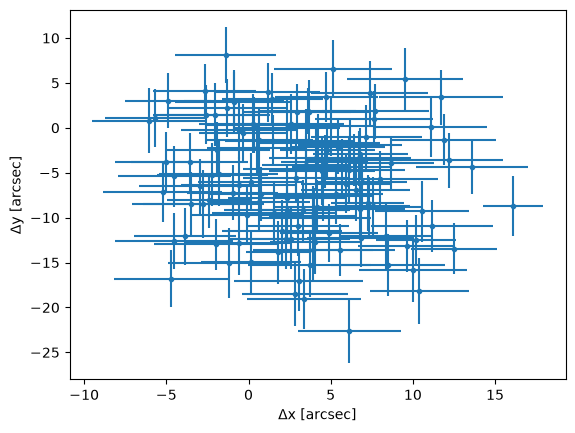

In [10]:
import matplotlib.pyplot as plt

dxdy = np.rad2deg(fitted.instrument.shift.value - nshift) * 3600

dx_err = np.rad2deg(errors.instrument.shift.value[:, 0]) * 3600
dy_err = np.rad2deg(errors.instrument.shift.value[:, 1]) * 3600
plt.errorbar(dxdy[:, 0], dxdy[:, 1], yerr=dy_err, xerr=dx_err, fmt=".")
plt.xlabel(r"$\Delta$x [arcsec]")
plt.ylabel(r"$\Delta$y [arcsec]")

The effect of the flatfielding (and us ignoring it in the fitting) leads to our error estimates not having the correct coverage! This shows how important it is to either include the pixel efficiencies in the fit or to have a good flatfielding estimate otherwise.

In [11]:
normed = np.concatenate([dxdy[:, 0] / dx_err, dxdy[:, 1] / dy_err])

within_1sig = np.mean(np.abs(normed) < 1)  # expect ~68%
within_2sig = np.mean(np.abs(normed) < 2)  # expect ~95%
print(f"1σ: {within_1sig:.0%}, 2σ: {within_2sig:.0%}")

1σ: 35%, 2σ: 63%
